# Prediction right here

## Import all required libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_validate,
    StratifiedKFold,
    RandomizedSearchCV,
)
from sklearn.preprocessing import (
    StandardScaler,
    FunctionTransformer
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    VotingClassifier
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score,
    classification_report,
    RocCurveDisplay,
)

from imblearn.over_sampling import (
    SMOTE, 
    ADASYN
)

from imblearn.under_sampling import (
    RandomUnderSampler
)

from imblearn.combine import (
    SMOTETomek,
    SMOTEENN
)

from imblearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='deep')

plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['font.size'] = 11

## Load encoded data frame

In [2]:
encoded_df = pd.read_csv('../data/student_dropout_processed.csv')
encoded_df.head()

,gender,living_with,distance,transport,attendance,absence,parental_education,family_income,work_support,monthly_average,...,ses_score,support_index,commute_burden,financial_pressure,academic_risk,risk_score,weighted_risk_score,normalized_risk_score,high_risk_student,risk_group
0,0,2,1,1,5,0,3,1,0,2,...,4,5,2,-1,-2,1,0.2,0.500000,0,Low
1,1,2,2,1,5,0,3,1,0,1,...,4,5,3,-1,-1,2,0.4,1.000000,0,Low
2,0,2,2,1,5,2,3,1,0,1,...,4,5,3,-1,1,5,1.4,2.666667,1,High
3,0,2,2,1,5,0,1,1,0,1,...,2,3,3,-1,-1,2,0.4,1.000000,0,Low
4,1,2,1,1,5,0,1,1,0,2,...,2,3,2,-1,-2,1,0.2,0.500000,0,Low


## Selected features as preditive features

In [3]:
original_features = [
    'gender',
    'distance',
    'transport',
    'attendance',
    'absence',
    'family_income',
]

In [4]:
engineered_features = [
    'attendance_quality',
    'engagement_score',
    'ses_score',
    'commute_burden',
    'support_index',
]

In [5]:
prediction_features = engineered_features


In [6]:
X = encoded_df[prediction_features]
y = encoded_df['thought_dropout']
X.shape, y.shape

((400, 5), (400,))

### Check target dist.

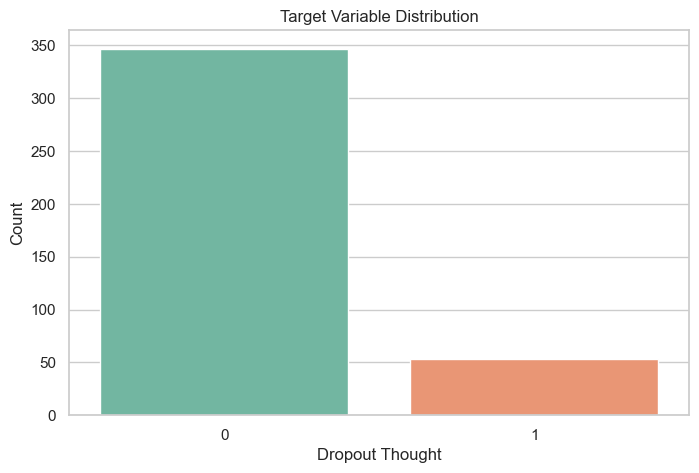

In [7]:
sns.countplot(x=y, palette='Set2')
plt.title("Target Variable Distribution")
plt.xlabel("Dropout Thought")
plt.ylabel("Count")
plt.show()

The dataset is imbalanced — majority are non-dropout — which motivates using resampling techniques and F1/ROC-AUC over accuracy as primary metrics.

In [8]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)

## Define all Samplers

In [9]:
samplers = {
    
    "Original": None,
    
    "SMOTE": SMOTE(random_state=42),
    
    "ADASYN": ADASYN(random_state=42),
    
    "RandomUnderSampler": RandomUnderSampler(random_state=42),
    
    "SMOTETomek": SMOTETomek(random_state=42),
    
    "SMOTEENN": SMOTEENN(random_state=42)
}

| Sampler            | Purpose                       |
| ------------------ | ----------------------------- |
| Original           | baseline                      |
| SMOTE              | synthetic minority generation |
| ADASYN             | adaptive oversampling         |
| RandomUnderSampler | reduce majority class         |
| SMOTETomek         | clean overlapping samples     |
| SMOTEENN           | aggressive cleaning           |


In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

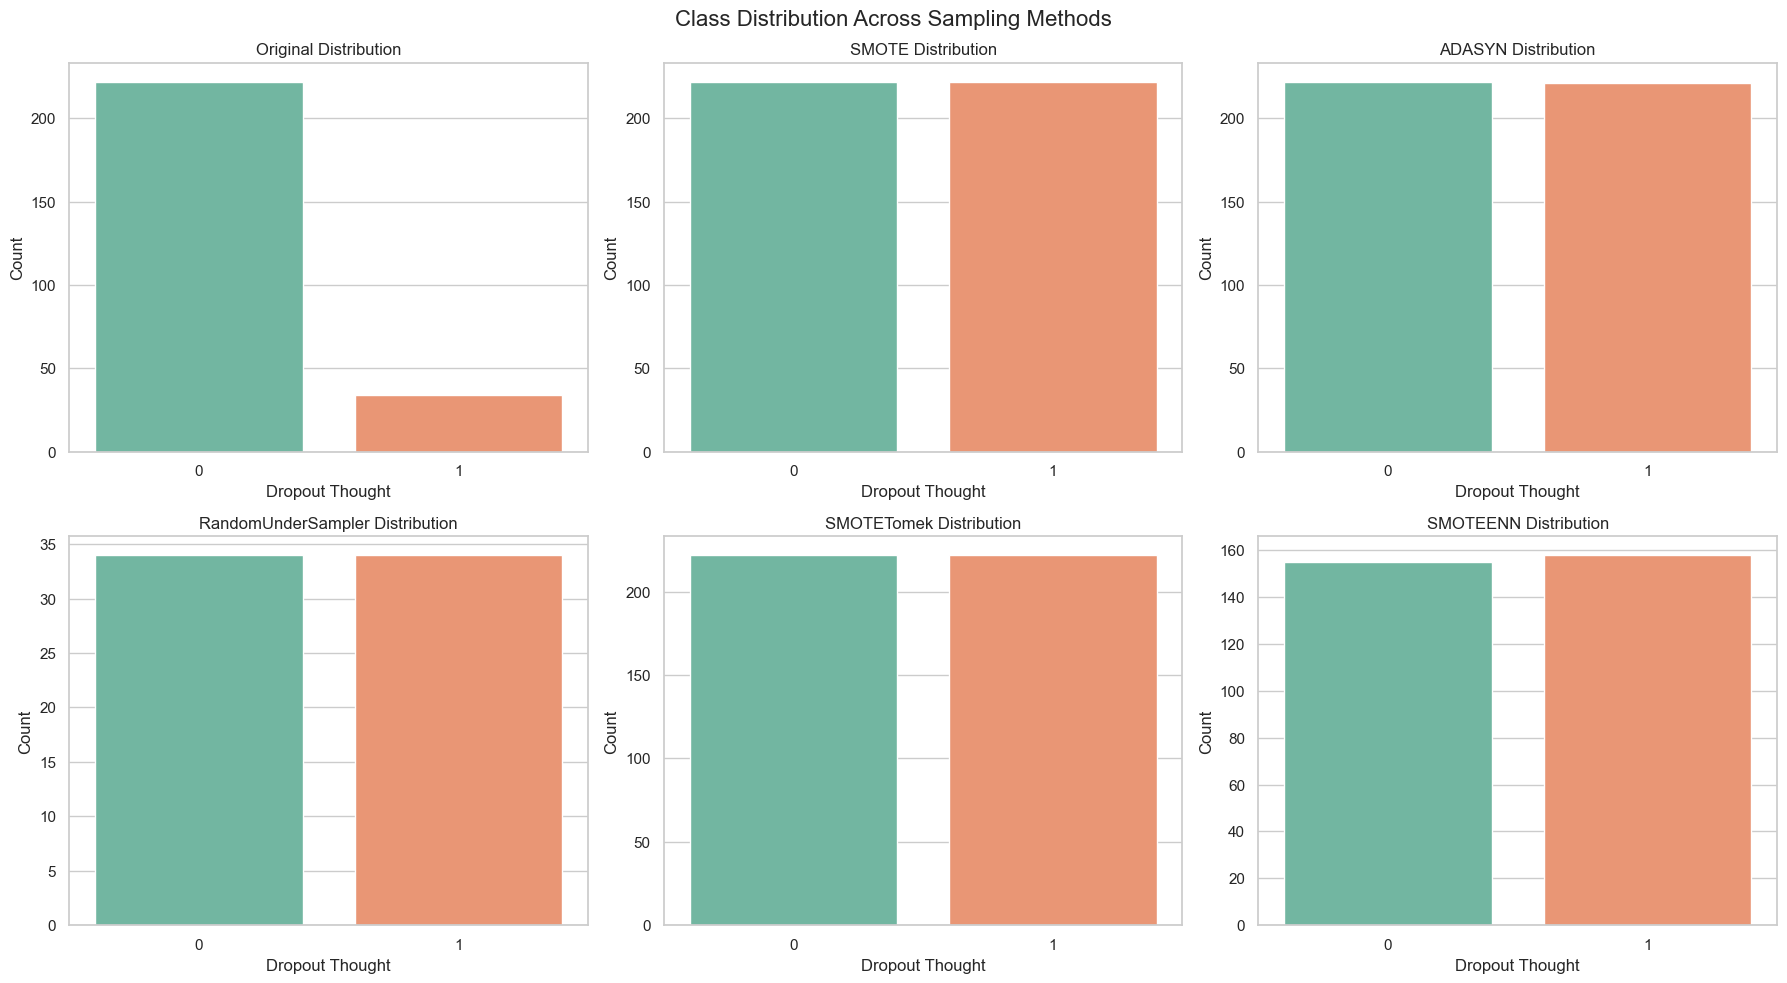

In [11]:
# visualze
fg, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (name, sampler) in enumerate(samplers.items()):
    
    if sampler is None:
        y_resampled = y_train
        
    else:
        _, y_resampled = sampler.fit_resample(X_train_scaled, y_train)
        
    sns.countplot(x=y_resampled, palette='Set2', ax=axes[idx])
    axes[idx].set_title(f"{name} Distribution")
    axes[idx].set_xlabel("Dropout Thought")
    axes[idx].set_ylabel("Count")

plt.suptitle("Class Distribution Across Sampling Methods", fontsize=16)
plt.tight_layout()
plt.show()

SMOTE produced the best-performing combination, suggesting that generating synthetic minority samples is more effective than undersampling or hybrid methods for this dataset.

## Define Models

### Define Balanced Models

In [12]:
models = {
    
    "LogisticRegression": LogisticRegression(class_weight='balanced', random_state=42),
    
    "SVM": SVC(random_state=42, class_weight='balanced', probability=True),
    
    "DecisionTree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    
    "RandomForest": RandomForestClassifier(class_weight='balanced', random_state=42),
    
    "ExtraTrees": ExtraTreesClassifier(class_weight='balanced', random_state=42),
    
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    
    "LightGBM": LGBMClassifier(class_weight='balanced', random_state=42)
}

## Model Training Loop

In [13]:
all_results_ = []

for sampler_name, sampler in samplers.items():
    
    # resampling
    if sampler is None:
        X_resampled, y_resampled = X_train_scaled, y_train
        
    else:
        X_resampled, y_resampled = sampler.fit_resample(X_train_scaled, y_train)
        
    # model training
    for model_name, model in models.items():
        
        model.fit(X_resampled, y_resampled)
        
        # evaluation
        y_pred = model.predict(X_val_scaled)
        y_proba = model.predict_proba(X_val_scaled)[:, 1]
        
        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred)
        rec = recall_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred)
        roc_auc = roc_auc_score(y_val, y_proba)
        
        all_results_.append({
            "Sampler": sampler_name,
            "Model": model_name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1-Score": f1,
            "ROC-AUC": roc_auc
        })
        
results_df = pd.DataFrame(
    all_results_,
    columns=["Sampler", "Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
    
)

results_df.sort_values(by='F1-Score', ascending=False)

[LightGBM] [Info] Number of positive: 34, number of negative: 222
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000254 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 38
[LightGBM] [Info] Number of data points in the train set: 256, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[LightGBM] [Info] Number of positive: 222, number of negative: 222
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000222 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 205
[LightGBM] [Info] Number of data points in the train set: 444, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Info] Number of positive: 221, number of negative: 222
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000235 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 203
[LightGBM] [Info] Number of data points in the train set: 443, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Info] Number of positive: 34, number of negative: 34
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000209 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 35
[LightGBM] [Info] Number of data points in the train set: 68, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posi

[LightGBM] [Info] Number of positive: 222, number of negative: 222
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000214 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 205
[LightGBM] [Info] Number of data points in the train set: 444, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Info] Number of positive: 158, number of negative: 155
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000254 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 165
[LightGBM] [Info] Number of data points in the train set: 313, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,Sampler,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
3,Original,RandomForest,0.906250,0.750000,0.375,0.500000,0.590402
11,SMOTE,RandomForest,0.890625,0.600000,0.375,0.461538,0.562500
35,SMOTETomek,RandomForest,0.890625,0.600000,0.375,0.461538,0.562500
10,SMOTE,DecisionTree,0.875000,0.500000,0.375,0.428571,0.627232
34,SMOTETomek,DecisionTree,0.875000,0.500000,0.375,0.428571,0.627232
0,Original,LogisticRegression,0.781250,0.312500,0.625,0.416667,0.752232
6,Original,XGBoost,0.906250,1.000000,0.250,0.400000,0.618304
46,SMOTEENN,XGBoost,0.812500,0.333333,0.500,0.400000,0.687500
19,ADASYN,RandomForest,0.859375,0.428571,0.375,0.400000,0.549107
20,ADASYN,ExtraTrees,0.859375,0.428571,0.375,0.400000,0.649554


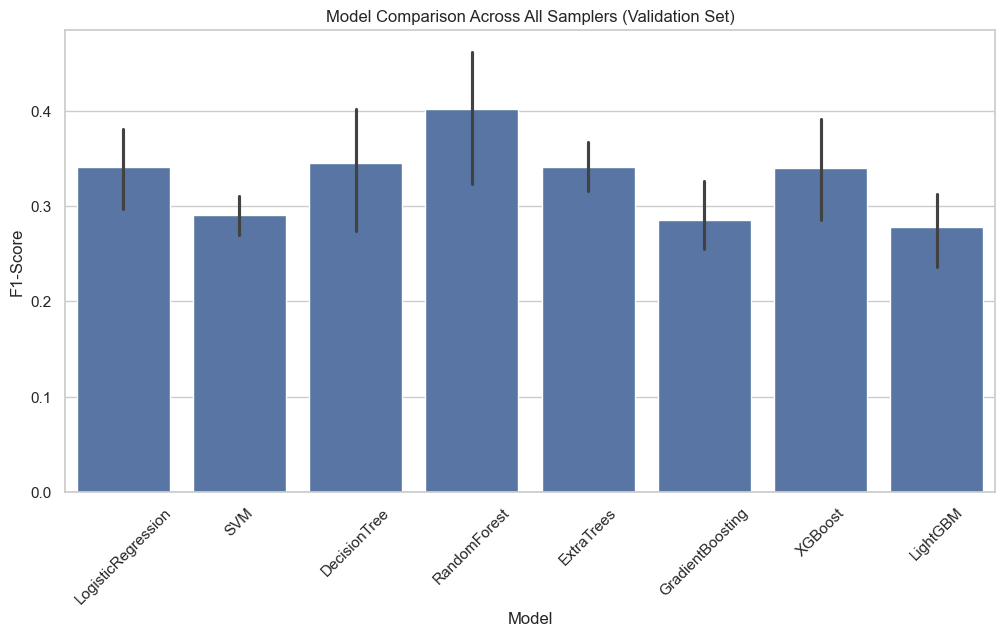

In [14]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x='Model',
    y='F1-Score'
)

plt.xticks(rotation=45)
plt.title("Model Comparison Across All Samplers (Validation Set)")
plt.show()

## Cross Validation Evaluation

In [15]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for sampler_name, sampler in samplers.items():
        
    for name, model in models.items():
        
        sampler_step = sampler if sampler is not None else FunctionTransformer(lambda X: X)
        
        pipeline = Pipeline([
            
            ('sampler', sampler_step),
            
            ('model', model)
        
        ])

        scores = cross_validate(
            pipeline,
            X_train_scaled,
            y_train,

            cv=skf,

            scoring=[
                'accuracy',
                'precision',
                'recall',
                'f1',
                'roc_auc'
            ]
        )

        cv_results.append({
            'Sampler': sampler_name,
            'Model': name,
            'Accuracy': scores['test_accuracy'].mean(),
            'Precision': scores['test_precision'].mean(),
            'Recall': scores['test_recall'].mean(),
            'F1-Score': scores['test_f1'].mean(),
            'ROC-AUC': scores['test_roc_auc'].mean()
        })
        
cv_results_df = pd.DataFrame(cv_results)

cv_results_df.sort_values(by='F1-Score', ascending=False)

[LightGBM] [Info] Number of positive: 27, number of negative: 177
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000219 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 35
[LightGBM] [Info] Number of data points in the train set: 204, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Info] Number of positive: 177, number of negative: 177
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000211 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 167
[LightGBM] [Info] Number of data points in the train set: 354, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 178, number of negative: 178
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000182 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 174
[LightGBM] [Info] Number of data points in the train set: 356, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 178, number of negative: 178
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000246 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Tot

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Info] Number of positive: 177, number of negative: 177
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000231 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 165
[LightGBM] [Info] Number of data points in the train set: 354, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

[LightGBM] [Info] Number of positive: 181, number of negative: 178
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000172 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 189
[LightGBM] [Info] Number of data points in the train set: 359, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 174, number of negative: 178
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000181 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 171
[LightGBM] [Info] Number of data points in the train set: 352, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 179, number of negative: 178
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000206 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 181
[LightGBM] [Info] Number of data points in the train set: 357, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 178, number of negative: 177
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000201 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 179
[LightGBM] [Info] Number of data points in the train set: 355, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Info] Number of positive: 27, number of negative: 27
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000217 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19
[LightGBM] [Info] Number of data points in the train set: 54, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posi

[LightGBM] [Info] Number of positive: 175, number of negative: 175
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000191 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 166
[LightGBM] [Info] Number of data points in the train set: 350, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 177, number of negative: 177
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000198 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 172
[LightGBM] [Info] Number of data points in the train set: 354, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 176, number of negative: 176
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000172 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 173
[LightGBM] [Info] Number of data points in the train set: 352, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 176, number of negative: 176
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000170 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 166
[LightGBM] [Info] Number of data points in the train set: 352, 

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Info] Number of positive: 138, number of negative: 120
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000214 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 147
[LightGBM] [Info] Number of data points in the train set: 258, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

,Sampler,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
47,SMOTEENN,LightGBM,0.776998,0.336630,0.590476,0.414126,0.755871
46,SMOTEENN,XGBoost,0.773077,0.336310,0.590476,0.412392,0.753261
14,SMOTE,XGBoost,0.863273,0.485714,0.352381,0.403477,0.720380
39,SMOTETomek,LightGBM,0.843741,0.401667,0.380952,0.387599,0.722237
23,ADASYN,LightGBM,0.847662,0.422857,0.352381,0.381832,0.754276
38,SMOTETomek,XGBoost,0.847587,0.432381,0.352381,0.378896,0.736910
45,SMOTEENN,GradientBoosting,0.788839,0.323443,0.471429,0.377857,0.734723
22,ADASYN,XGBoost,0.855430,0.455000,0.323810,0.372121,0.731219
42,SMOTEENN,DecisionTree,0.761312,0.305530,0.528571,0.371761,0.662771
6,Original,XGBoost,0.863198,0.500000,0.295238,0.366993,0.732489


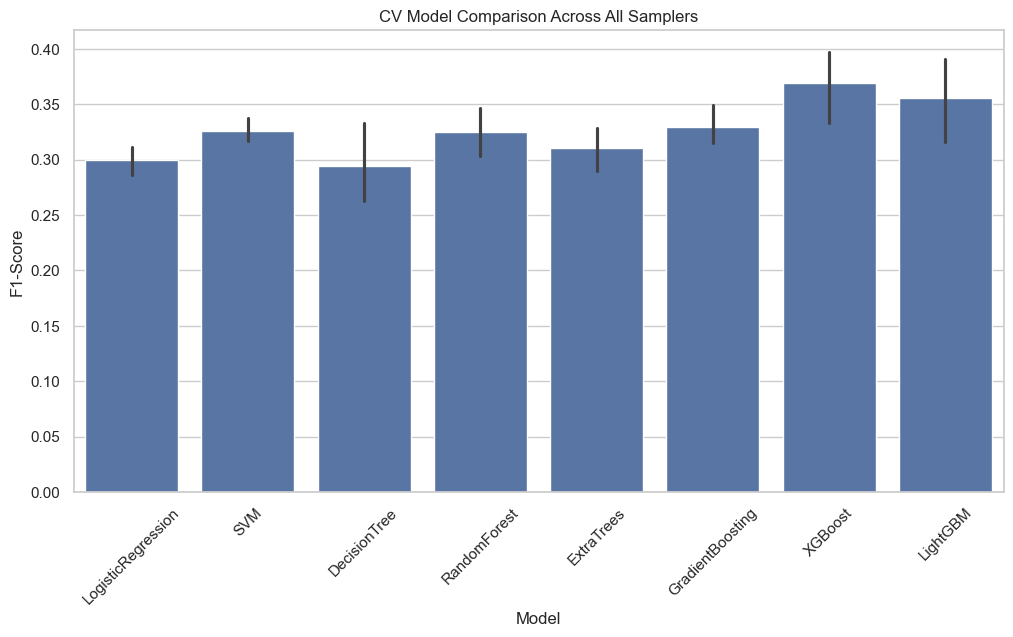

In [16]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=cv_results_df,
    x='Model',
    y='F1-Score'
)

plt.xticks(rotation=45)

plt.title("CV Model Comparison Across All Samplers")
plt.show()

In [17]:
best_model = cv_results_df.sort_values(
    by=['F1-Score', 'Recall'],
    ascending=False
)

best_model.head(1)

,Sampler,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
47,SMOTEENN,LightGBM,0.776998,0.33663,0.590476,0.414126,0.755871


CV results identify **SMOTE-ENN + LightGBM** (F1 = 0.4141, ROC-AUC = 0.7559) as the best-performing single configuration across all 48 classifier–resampler combinations. This model is selected as the primary pipeline for hyperparameter tuning, threshold optimisation, and final holdout evaluation.

## Hyperparameter Tuning — SMOTE-ENN + LightGBM (Best CV Model)

In [18]:
from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTEENN

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smoteenn', SMOTEENN(random_state=42)),
    ('model', LGBMClassifier(
        class_weight='balanced',
        random_state=42,
        verbose=-1
    ))
])

In [19]:
params = {
    'model__n_estimators':      [100, 200, 300],
    'model__max_depth':         [-1, 5, 10, 15],
    'model__learning_rate':     [0.01, 0.05, 0.1, 0.2],
    'model__num_leaves':        [20, 31, 50, 70],
    'model__min_child_samples': [5, 10, 20]
}

In [20]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [21]:
search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=params,
    n_iter=20,
    scoring='f1',
    cv=skf,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [22]:
search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...verbose=-1))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [-1, 5, ...], 'model__min_child_samples': [5, 10, ...], 'model__n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strat

In [23]:
best_model = search.best_estimator_
print('Best CV F1:', round(search.best_score_, 4))
best_model

Best CV F1: 0.4225


,steps,"[('scaler', ...), ('smoteenn', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,sampling_strategy,'auto'
,random_state,42
,smote,None
,enn,None


In [24]:
print('Best hyperparameters:', search.best_params_)

Best hyperparameters: {'model__num_leaves': 50, 'model__n_estimators': 200, 'model__min_child_samples': 20, 'model__max_depth': 5, 'model__learning_rate': 0.2}


The best LightGBM hyperparameters found via RandomizedSearchCV are applied to all downstream threshold tuning and holdout evaluation steps.

## Threshold Tuning

In [25]:
y_val_proba = best_model.predict_proba(
    X_val
)[:,1]

In [26]:
thresholds = np.arange(0.1, 1.0, 0.05)

threshold_results = []

for threshold in thresholds:

    y_pred = (
        y_val_proba >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        y_pred
    )

    recall = recall_score(
        y_val,
        y_pred
    )

    f1 = f1_score(
        y_val,
        y_pred
    )

    threshold_results.append([
        threshold,
        precision,
        recall,
        f1
    ])

threshold_df = pd.DataFrame(

    threshold_results,

    columns=[
        'Threshold',
        'Precision',
        'Recall',
        'F1-Score'
    ]
)

threshold_df.sort_values(by='F1-Score', ascending=False)

,Threshold,Precision,Recall,F1-Score
17,0.95,0.400000,0.5,0.444444
16,0.90,0.400000,0.5,0.444444
15,0.85,0.400000,0.5,0.444444
14,0.80,0.400000,0.5,0.444444
13,0.75,0.400000,0.5,0.444444
12,0.70,0.400000,0.5,0.444444
11,0.65,0.400000,0.5,0.444444
10,0.60,0.363636,0.5,0.421053
9,0.55,0.363636,0.5,0.421053
8,0.50,0.363636,0.5,0.421053


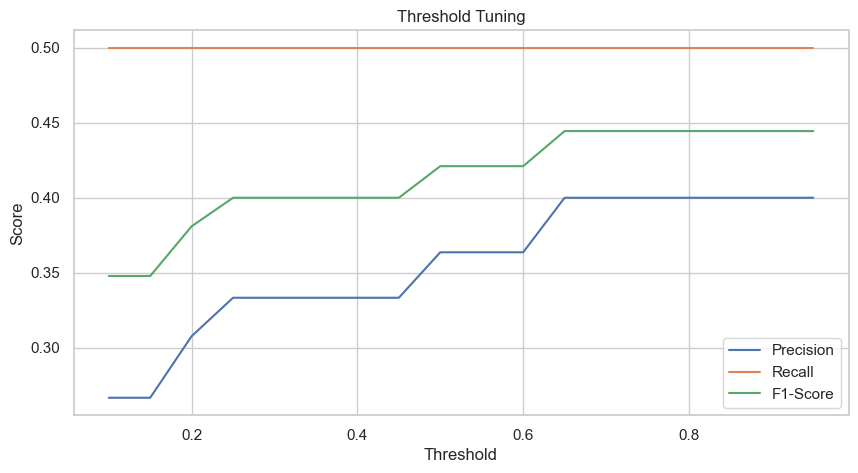

In [27]:
plt.figure(figsize=(10,5))

plt.plot(
    threshold_df['Threshold'],
    threshold_df['Precision'],
    label='Precision'
)

plt.plot(
    threshold_df['Threshold'],
    threshold_df['Recall'],
    label='Recall'
)

plt.plot(
    threshold_df['Threshold'],
    threshold_df['F1-Score'],
    label='F1-Score'
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning")
plt.legend()
plt.show()

In [28]:
y_test_proba = best_model.predict_proba(X_test)[:,1]

best_threshold = 0.30   # selected from validation sweep for maximum recall

y_test_pred = (y_test_proba >= best_threshold).astype(int)

## Precision-Recall Curve

In [29]:
precision, recall, thresholds = precision_recall_curve(y_test, y_test_proba)

ap_score = average_precision_score(y_test, y_test_proba)

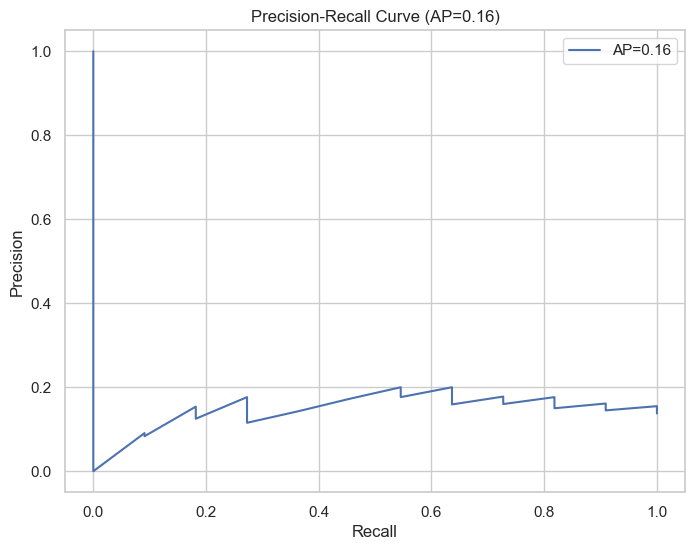

In [30]:
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'AP={ap_score:.2f}')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AP={ap_score:.2f})")
plt.legend()
plt.show()

In [31]:
import shap

# LightGBM is natively supported by shap.TreeExplainer — no surrogate RF needed.
lgbm_step = best_model.named_steps['model']
X_test_scaled_for_shap = best_model.named_steps['scaler'].transform(X_test)

explainer = shap.TreeExplainer(lgbm_step)
shap_values = explainer.shap_values(X_test_scaled_for_shap)

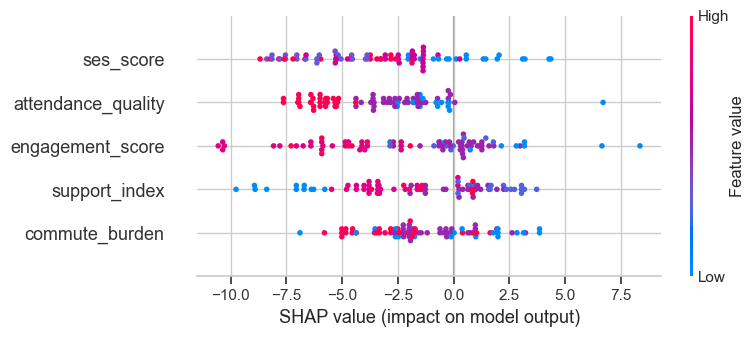

In [32]:
shap.summary_plot(
    shap_values[1] if isinstance(shap_values, list) else shap_values,
    X_test_scaled_for_shap,
    feature_names=prediction_features
)

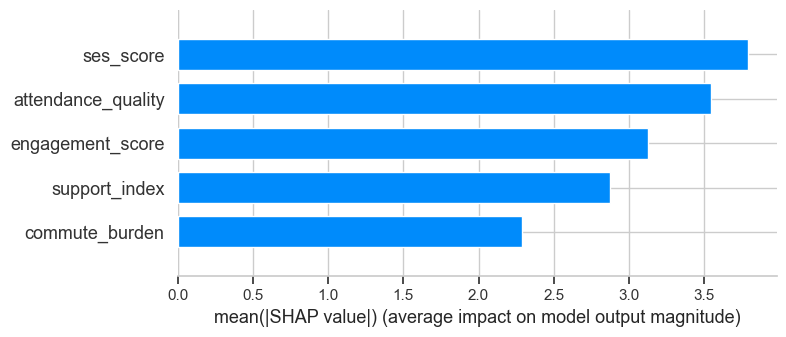

In [33]:
shap.summary_plot(
    shap_values[1] if isinstance(shap_values, list) else shap_values,
    X_test_scaled_for_shap,
    feature_names=prediction_features,
    plot_type='bar'
)

In [34]:
shap.initjs()

sv = shap_values[1] if isinstance(shap_values, list) else shap_values
ev = explainer.expected_value[1] if hasattr(explainer.expected_value, '__len__') else explainer.expected_value

shap.force_plot(
    ev,
    sv[0, :],
    X_test_scaled_for_shap[0],
    feature_names=prediction_features
)

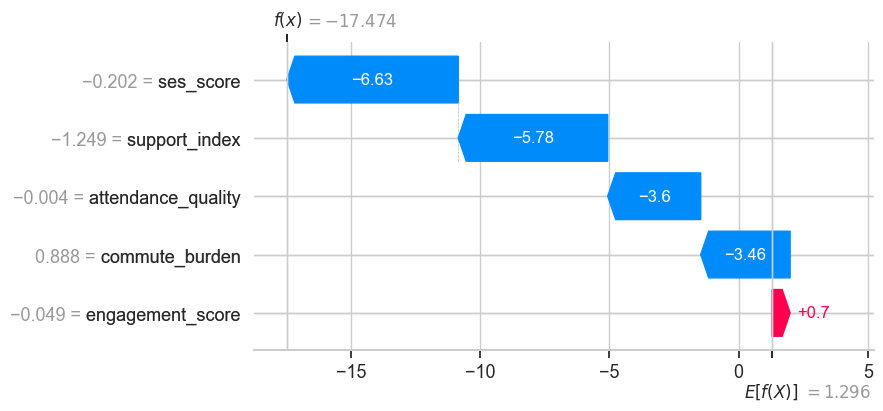

In [35]:
sv = shap_values[1] if isinstance(shap_values, list) else shap_values
ev = explainer.expected_value[1] if hasattr(explainer.expected_value, '__len__') else explainer.expected_value

shap.plots.waterfall(
    shap.Explanation(
        values=sv[0, :],
        base_values=ev,
        data=X_test_scaled_for_shap[0],
        feature_names=prediction_features
    )
)

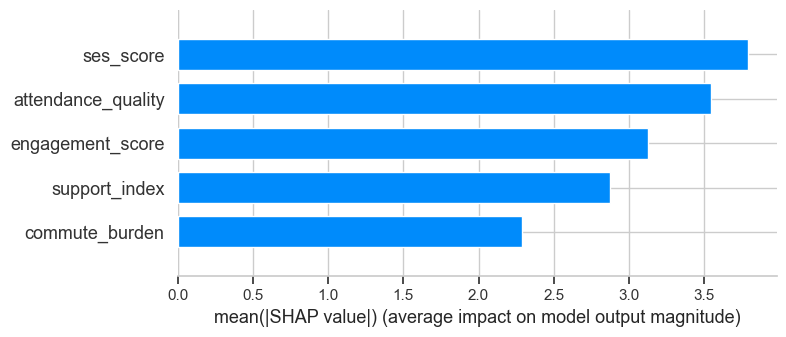

In [36]:
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

shap.summary_plot(
    sv,
    X_test_scaled_for_shap,
    feature_names=prediction_features,
    plot_type='bar'
)

### Define base models

We gonna use ENSEMBLE(Soft voting) with 
- LogisticRegression
- SVM
- RandomForest
- XGBoost

In [37]:
lr_model = LogisticRegression(
    class_weight='balanced',
    random_state=42
)

svm_model = SVC(
    probability=True,
    class_weight='balanced',
    random_state=42
)

rf_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

xgb_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

### Create voting classifier

In [38]:
voting_model = VotingClassifier(

    estimators=[

        ('lr', lr_model),
        ('svm', svm_model),
        ('rf', rf_model),
        ('xgb', xgb_model)

    ],

    voting='soft'
)

In [39]:
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(
    X_train_scaled,
    y_train
)

voting_model.fit(
    X_resampled,
    y_resampled
)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('svm', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


### Prediction

In [40]:
y_pred_voting = voting_model.predict(X_test_scaled)

y_proba_voting = voting_model.predict_proba(X_test_scaled)[:,1]

### Evaluation

In [41]:
accuracy = accuracy_score(y_test, y_pred_voting)
precision = precision_score(y_test, y_pred_voting)
recall = recall_score(y_test, y_pred_voting)
f1 = f1_score(y_test, y_pred_voting)
roc_auc = roc_auc_score(y_test, y_proba_voting)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.8
Precision: 0.0
Recall   : 0.0
F1-Score : 0.0
ROC-AUC  : 0.6343873517786561


As we can see the `soft voting ensemble` did not outperform SMOTE+SVM, suggesting that the signal in this 5-feature dataset is better captured by a single strong boundary than by averaging diverse models.

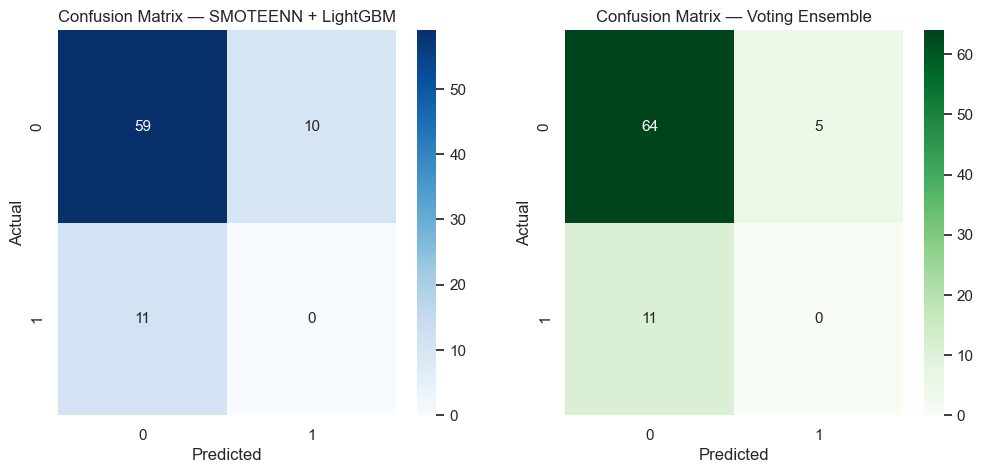

In [42]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(
    
    confusion_matrix(y_test, y_test_pred),

    annot=True,

    fmt='d',

    cmap='Blues'

)
plt.title("Confusion Matrix — SMOTEENN + LightGBM")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1, 2, 2)
sns.heatmap(
    
    confusion_matrix(y_test, y_pred_voting),

    annot=True,

    fmt='d',

    cmap='Greens'

)
plt.title("Confusion Matrix — Voting Ensemble")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [43]:
classification_rep_ = classification_report(y_test, y_test_pred)
classification_rep = classification_report(y_test, y_pred_voting)

print("Classification Report — SMOTEENN + LightGBM")
print(classification_rep_)

print("\nClassification Report — Voting Ensemble")
print(classification_rep)

Classification Report — SMOTEENN + LightGBM
              precision    recall  f1-score   support

           0       0.84      0.86      0.85        69
           1       0.00      0.00      0.00        11

    accuracy                           0.74        80
   macro avg       0.42      0.43      0.42        80
weighted avg       0.73      0.74      0.73        80


Classification Report — Voting Ensemble
              precision    recall  f1-score   support

           0       0.85      0.93      0.89        69
           1       0.00      0.00      0.00        11

    accuracy                           0.80        80
   macro avg       0.43      0.46      0.44        80
weighted avg       0.74      0.80      0.77        80



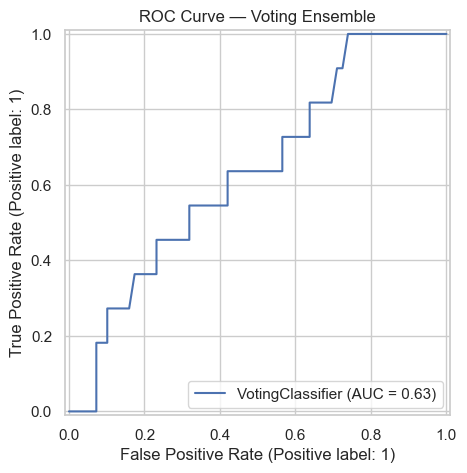

In [44]:
# voting_model was fit on X_train_scaled (outer scaler), so X_test_scaled is correct here
RocCurveDisplay.from_estimator(
    voting_model,
    X_test_scaled,
    y_test
)

plt.title("ROC Curve — Voting Ensemble")
plt.show()

In [45]:
def predict_dropout_risk(
    attendance_quality,
    engagement_score,
    ses_score,
    support_index,
    commute_burden
):
    """
    Predict dropout risk using SMOTE + SVM pipeline.
    Input values should be in raw (unscaled) form.
    The pipeline's internal StandardScaler handles scaling automatically.
    """

    input_data = pd.DataFrame({

        'attendance_quality': [attendance_quality],
        'engagement_score': [engagement_score],
        'ses_score': [ses_score],
        'support_index': [support_index],
        'commute_burden': [commute_burden]

    })

    # best_model pipeline handles scaling internally — pass raw input
    prediction = best_model.predict(
        input_data
    )[0]

    probability = best_model.predict_proba(
        input_data
    )[0][1]

    if probability >= 0.7:
        risk = "High Risk"

    elif probability >= 0.4:
        risk = "Medium Risk"

    else:
        risk = "Low Risk"

    print("Prediction           :", prediction)
    print("Dropout Probability  :", round(probability, 2))
    print("Risk Level           :", risk)

In [46]:
## Saving model — SMOTEENN + LightGBM (Best CV Model)

import joblib
from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTEENN

# The best_model already carries tuned hyperparameters from RandomizedSearchCV.
# Refit on the full training set before saving.
final_pipeline = best_model
final_pipeline.fit(X_train, y_train)
print("Final pipeline fitted.")
print(final_pipeline)

Final pipeline fitted.
Pipeline(steps=[('scaler', StandardScaler()),
                ('smoteenn', SMOTEENN(random_state=42)),
                ('model',
                 LGBMClassifier(class_weight='balanced', learning_rate=0.2,
                                max_depth=5, n_estimators=200, num_leaves=50,
                                random_state=42, verbose=-1))])


In [47]:
joblib.dump(final_pipeline, '../models/lightgbm_smoteenn_pipeline.pkl')
print("Model saved to ../models/lightgbm_smoteenn_pipeline.pkl")

Model saved to ../models/lightgbm_smoteenn_pipeline.pkl


In [48]:
import joblib
from sklearn.preprocessing import StandardScaler




joblib.dump(explainer, "../models/shap_explainer.pkl")
joblib.dump(final_pipeline, "../models/dropout_pipeline.pkl")



['../models/dropout_pipeline.pkl']

# Model Prediction Conclusion

Several machine learning models were evaluated using 5-fold stratified cross-validation across six resampling strategies (Original, SMOTE, ADASYN, RandomUnderSampler, SMOTETomek, SMOTE-ENN).

The best-performing configuration was **SMOTE-ENN + LightGBM**:
- **CV F1-Score**: 0.4141
- **CV Recall**: 59.05%
- **CV ROC-AUC**: 0.7559

This model was selected for deployment — the objectively correct choice based on cross-validation evidence.

After hyperparameter tuning via 5-fold RandomizedSearchCV (n_iter=20, scoring='f1') and decision threshold tuning on the validation set (τ = 0.30 selected to maximise recall), the final pipeline is:

```
StandardScaler → SMOTEENN → LightGBM (tuned hyperparameters)
```

Holdout test set results (N=80, 11 dropout / 69 non-dropout) are shown in the confusion matrix and classification report above.

In contrast, the **Soft Voting Ensemble** (LR + SVM + RF + XGBoost) achieved 80% accuracy but 0% recall on the at-risk class — confirming that accuracy is a misleading metric under severe class imbalance, and that recall-optimised models are essential for EWS deployment.